___
# **Assignment 10 -- PCA**
## Points -- 20
## Instructor -- Rizwan Ahmad (ahmad.46@osu.edu)
## BME5710 -- Spring 2026


___
### Instructions: Provide single-line or multi-line code between `### begin code block` and `### end code block`, small missing fragment in the code at `?code?`, and non-coding answers at `???`

### You may use AI tools to clarify concepts and for coding, but using them to directly answer the assignment questions is not allowed.

___
### Write your name here

Answer: Evan Gilligan

___
### Import libraries and sub-libraries.

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml


___
### Calling a custom code to change the default font for figures to `Computer Modern`. (Optional)

In [58]:
from fontsetting import font_cmu
plt = font_cmu(plt)

___
### (1.1 -- 0.0 pt) Load the MNIST data into $\boldsymbol{X}_{\sf all} \in \mathbb{R}^{70000\times 784}$ matrix. Note, each row is a vectorized version of a $28 \times 28$ image. Nothing to do here.

In [59]:
rng = np.random.default_rng(seed=0) # Seed for random number generation
mnist = fetch_openml('mnist_784', version=1, cache=True, parser='auto') # Fetch the MNIST dataset; you may need to delete parser='auto', depending on your version of scikit-learn
max_value = np.max(mnist.data.values) # Find the maximum value in the dataset
X_all = np.array(2 * (mnist.data.values / max_value - 0.5)) # Normalize the data to [-1, 1] and convert it to a numpy array 
nx = X_all.shape[1] # dimension of input data
print(X_all.shape)

(70000, 784)


___
### (1.2 -- 2.0 pt) Load the first 12,000 MNIST images into a matrix $\boldsymbol{X} \in \mathbb{R}^{12000\times 784}$. Then, load the $12{,}001^{\sf th}$ sample into matrix $\boldsymbol{X}_{\sf test} \in \mathbb{R}^{1\times 784}$. Center the rows of both $\boldsymbol{X}$ and $\boldsymbol{X}_{\sf test}$ by subtracting $\boldsymbol{\mu} \in \mathbb{R}^{1\times 784}$. Note, the mean $\boldsymbol{\mu}$ should be computed by averaging the rows of $\boldsymbol{X}$ and should not come from $\boldsymbol{X}_{\sf test}$.


In [60]:
### begin code block
X = X_all[:12000] 
X_test = X_all[12000:12001]
mu = np.mean(X, axis=0)
X = X - mu
X_test = X_test - mu

### end code block

print(X.shape)
print(mu.shape)
print(X_test.shape)


(12000, 784)
(784,)
(1, 784)


___
### (1.3 -- 3.0 pt) Perform reduced (economy) SVD of centered-$\boldsymbol{X}$ using `np.linalg.svd` to compute $\boldsymbol{U}$, $\boldsymbol{D}$, and $\boldsymbol{V}^{\sf T}$. Then print out the sizes of these three matrices.

#### To save memory, this svd command does not generate $\boldsymbol{D}$ directly, but it gives out a vector $d$, which contains the diagonal entries of $\boldsymbol{D}$. But you can convert these entries into the diagonal matrix $\boldsymbol{D}$ using `np.fill_diagonal(D, d)`. See Demo 20.

In [61]:
### begin code block
U,d,VT = np.linalg.svd(X, full_matrices=False) 
D = np.zeros((len(d), len(d))) 
np.fill_diagonal(D, d) 

### end code block
print(U.shape, D.shape, VT.shape)

(12000, 784) (784, 784) (784, 784)


___
### (1.4 -- 2.0 pt) Display the first 16 eigenvectors (reshaped back to sixteen $28\times 28$ eigenimages), each on the scale of $-0.15$ to $+0.15$. For colormap, use `cmap='bwr'`


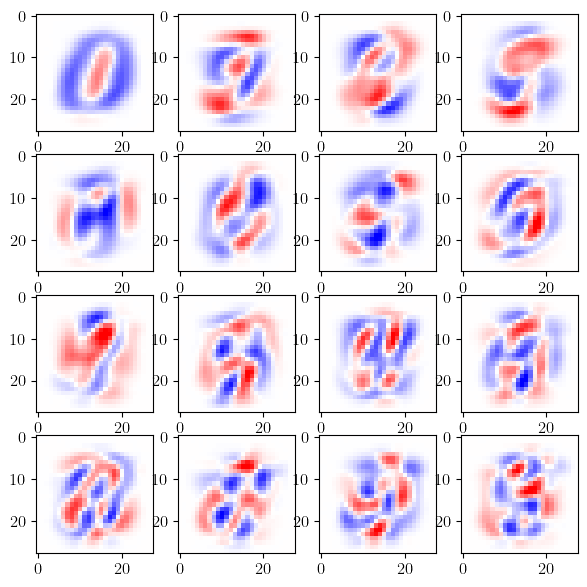

In [62]:
fig, axes = plt.subplots(4, 4, figsize=(7, 7))

### begin code block

for i in range(16):
    EV = VT[i,:]
    EI = EV.reshape(28,28)
    axes.flat[i].imshow(EI, cmap='bwr', vmin=-0.15, vmax=0.15)
    
plt.show()

    
### end code block

___
### (1.5 -- 1.0 pt) We have been referring to the principal components as an orthonormal coordinate system. Explain why the set of all eigenvectors (principal components) forms a basis for the data space.


Answer: To prove that some set of vectors creates a basis for the data they must be linearly independent and span across the vector space. The principal components are the eigenvectors of the covariance matrix. Because the covariance matrix is symmetric, its eigenvectors are then linearly independent. Additionally, in a data space with n dimensions, there are up to n eigenvectors or principal components. This allows the principal components to span the data space. Therefore, because the principal components are linearly independent and span the data space, they then form a basis for the data space. 

___
### (1.6 -- 2.0 pt) Using a figure, show that all 16 PCs are of unit norm and are mutually orthogonal


Norms of the 16 PCs:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


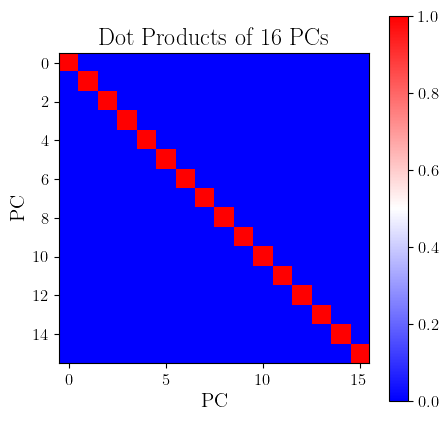

In [63]:
### begin code block
PC = VT[:16, :]

pc_norms = np.linalg.norm(PC, axis=1)
print("Norms of the 16 PCs:")
print(pc_norms) # Should all be 1 (unit norm)
prod = PC @ PC.T # should give identity matrix 

plt.figure(figsize=(5,5))
plt.imshow(prod, cmap='bwr')
plt.colorbar()
plt.title('Dot Products of 16 PCs')
plt.xlabel('PC')
plt.ylabel('PC')
plt.show()

# The diagonal giving values of 1 confirms that each PC has unit norm. Off-diagonal values giving value of 0 confirms PCs are orthogonal. 

### end code block

___
### (1.7 -- 3.0 pt) On two different subplots, plot eigenvalues and the proportion of variance (PoV). Also, compute the minimum value of the rank $r$ needed for PoV to reach 60, 85, and 99\%, respectively. Call these values `r60`, `r85`, and `r99`, respectively.


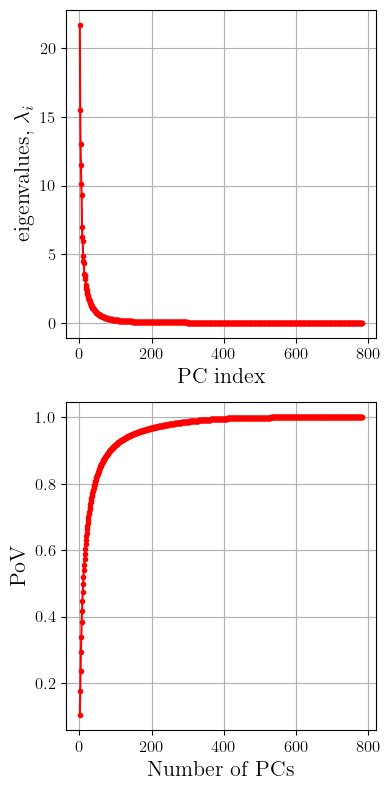

Minimum rank for PoV to reach 60%: 16
Minimum rank for PoV to reach 85%: 58
Minimum rank for PoV to reach 99%: 325


In [66]:
### begin code block
fig, axes = plt.subplots(2, 1, figsize=(4,8), facecolor='#ffffff', edgecolor=None) 

m = X.shape[0] 
n = X.shape[1] 

lam = d**2 / m 
PoV = np.cumsum(lam)/np.sum(lam) 

# Eigenvalue Spectrum
axes[0].plot(np.arange(1,np.min([m,n])+1), lam,'r.-') 
axes[0].grid()
axes[0].tick_params(axis='x', labelsize=12)
axes[0].tick_params(axis='y', labelsize=12)
axes[0].set_xlabel('PC index', fontsize=16)
axes[0].set_ylabel(r'eigenvalues, $\lambda_i$', fontsize=16)

# PoV curve
axes[1].plot(np.arange(1,np.min([m,n])+1), PoV,'r.-') 
axes[1].grid()
axes[1].tick_params(axis='x', labelsize=12)
axes[1].tick_params(axis='y', labelsize=12)
axes[1].set_xlabel('Number of PCs', fontsize=16)
axes[1].set_ylabel('PoV', fontsize=16)

plt.tight_layout() 

plt.show()

r_60 = 0
r_85 = 0
r_99 = 0

for i in range(PoV.shape[0]):
    if r_60 == 0 and PoV[i] >= 0.60:
        r_60 = i + 1
    if r_85 == 0 and PoV[i] >= 0.85:
        r_85 = i + 1
    if r_99 == 0 and PoV[i] >= 0.99:
        r_99 = i + 1
        break

print(f"Minimum rank for PoV to reach 60%: {r_60}")
print(f"Minimum rank for PoV to reach 85%: {r_85}")
print(f"Minimum rank for PoV to reach 99%: {r_99}")

### end code block

___
### (1.8 -- 1.0 pt) Explain why the PoV approaches 1 as the number of retained principal components $r$ approaches the rank of $\boldsymbol{X}$.


Answer: The PoV is the fraction of the total variance that is explained by the retained principal components. As more principal components are added, more sources of variance are included, bringing the total closer to accounting for 100% of the variance. When all components are included (r = X), all variance is accounted for and the PoV reaches 1.

___
### (1.9 -- 2.5 pt) Now, approximate $\boldsymbol{X}_{\sf test}$ using the first $r60$, $r85$, and $r99$ eigenvectors. To compute approximations, use $\widehat{\boldsymbol{x}}_{r60}^{(i)} = \boldsymbol{V}_{r60}\boldsymbol{z}_{r60}^{(i)}$ with $\boldsymbol{z}_{r60}^{(i)} = \boldsymbol{V}_{r60}^{\sf T} \boldsymbol{x}^{(i)}$ from Slide 19 of Module 11. Display the three approximations as well as the original image.

Note, do not forget to add $\boldsymbol{\mu}$ back to the approximated test images.


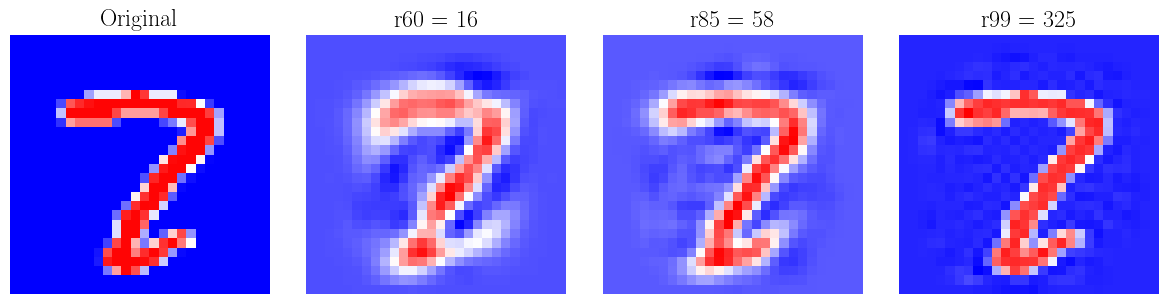

In [77]:
### begin code block

# Calculate v
V = VT.T
V_r60 = V[:, :r_60]
V_r85 = V[:, :r_85]
V_r99 = V[:, :r_99]

# Calculate z
z_r60 = V_r60.T @ X_test[0,:]
z_r85 = V_r85.T @ X_test[0,:]
z_r99 = V_r99.T @ X_test[0,:]

# Calculate xhat
xhat_r60 = (V_r60 @ z_r60) + mu
xhat_r85 = (V_r85 @ z_r85) + mu
xhat_r99 = (V_r99 @ z_r99) + mu

# Plot
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

# Original 
x_0 = X_test[0, :] + mu
axes[0].imshow(x_0.reshape(28,28), cmap='bwr')
axes[0].set_title("Original")
axes[0].axis("off")

# r60
axes[1].imshow(xhat_r60.reshape(28,28), cmap='bwr')
axes[1].set_title(f"r60 = {r_60}")
axes[1].axis("off")

# r85
axes[2].imshow(xhat_r85.reshape(28,28), cmap='bwr')
axes[2].set_title(f"r85 = {r_85}")
axes[2].axis("off")

# r99
axes[3].imshow(xhat_r99.reshape(28,28), cmap='bwr')
axes[3].set_title(f"r99 = {r_99}")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### end code block

___
### (1.10 -- 2.5 pt) Assume you are satisfied with the quality of $\widehat{\boldsymbol{x}}_{r99}$ images. Now, consider a scenario where you cannot afford to save all 70,000 original MNIST images due to storage limitations. Instead of storing the raw images, you decide to store a compact PCA-based representation. What information must be saved so that any of the 70,000 MNIST images can be reconstructed approximately? Compute the total storage required for this PCA representation (in units of floating-point numbers) and compare it to the original storage cost. What percentage of storage is saved?


Answer: ???


___
*This was the very last assignment, yay!*